<a href="https://colab.research.google.com/github/k242565-art/flyrank-ml-internship/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/k242565-art/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*
| Rank | Action              | Reason Code      | Description                          |
| ---- | ------------------- | ---------------- | ------------------------------------ |
| 1    | Refresh Immediately | STALE_DECLINE    | Old content with declining traffic   |
| 2    | Refresh Soon        | STALE_HIGH_VALUE | High search volume but aging content |
| 3    | CTR Optimization    | LOW_CTR          | Good ranking but poor CTR            |
| 4    | Monitor             | WATCHLIST        | Mixed signals                        |
| 5    | No Action           | HEALTHY          | Content performing normally          |
Reason Codes
STALE_DECLINE
Content has not been updated recently and traffic trend is negative.
STALE_HIGH_VALUE
Content is aging but still targets valuable search demand.
LOW_CTR
Search position is acceptable but CTR is below expected level.
WATCHLIST
Signals are mixed and require observation before intervention.
HEALTHY
Performance indicators do not currently suggest refresh action.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def assign_action(row):

    if row["days_since_last_update"] > 180 and row["trend_pct"] < -20:
        return "Refresh Immediately", "STALE_DECLINE"

    elif row["days_since_last_update"] > 120 and row["search_volume"] > 1000:
        return "Refresh Soon", "STALE_HIGH_VALUE"

    elif row["ctr"] < 2 and row["avg_position"] < 10:
        return "CTR Optimization", "LOW_CTR"

    else:
        return "Monitor", "WATCHLIST"

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
This playbook is intended as a decision-support tool.

The output provides ranked content-review recommendations and should be used to prioritize editorial effort.

The playbook does not automatically modify content and should not be interpreted as proof that a refresh will improve performance.
Limitations

• Built on anonymized historical data.
• Does not measure actual SEO impact after refresh.
• Cannot determine content quality.
• Cannot identify factual inaccuracies.
• Does not account for seasonality.
• Recommendations are directional rather than guaranteed.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
Every recommendation should be reviewed by a content owner before action.

Review should confirm:

1. Topic is still relevant.
2. Search demand still exists.
3. Content is factually correct.
4. Traffic decline is not seasonal.
5. Business priorities justify refresh effort.

Do not automatically:

• Publish new content.
• Delete content.
• Rewrite content.
• Change medical, legal, or financial information.
• Update pricing information.
• Remove pages.
• Modify customer-facing content without review.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
Retrain if:

• Traffic distribution changes significantly.
• New client groups are added.
• Model F1 drops below previous validation results.
• New content formats appear.
Review recommendations if:

• Traffic drops >20%.
• CTR drops >15%.
• Search position changes significantly.
• Content exceeds 180 days without update.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

/content
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv
/content
fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.
Export complete
/content


<Figure size 640x480 with 0 Axes>

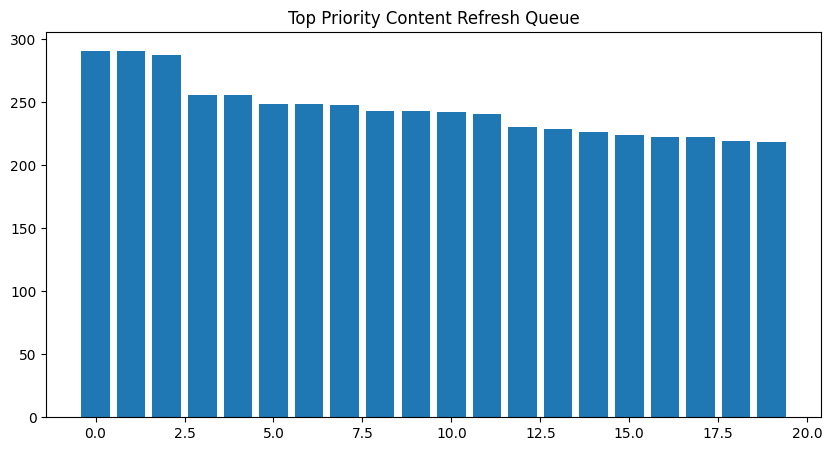

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
print(os.getcwd())
!find /content -name "content_refresh_anonymized.csv"
%cd /content
!git clone https://github.com/k242565-art/flyrank-ml-internship.git
import pandas as pd

df = pd.read_csv(
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)
import os

os.makedirs(
    "work/outputs",
    exist_ok=True
)
queue = df.copy()

queue["priority_score"] = (
    queue["days_since_last_update"] * 0.7
    +
    (-queue["trend_pct"].clip(upper=0)) * 0.3
)

queue = queue.sort_values(
    "priority_score",
    ascending=False
)
queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

print("Export complete")
import os

os.makedirs("work/figures", exist_ok=True)
plt.savefig(
    "work/figures/top_priority_queue.png",
    bbox_inches="tight"
)
import os
print(os.getcwd())
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

plt.savefig(
    "work/figures/top_priority_queue.png",
    bbox_inches="tight"
)
import matplotlib.pyplot as plt

top_actions = queue.head(20)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_actions)),
    top_actions["priority_score"]
)

plt.title("Top Priority Content Refresh Queue")

plt.savefig(
    "work/figures/top_priority_queue.png",
    bbox_inches="tight"
)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.